# Real-asteroid evaluation — v7 + RF (leak-free) vs LSST 5σ stack

Mirror of `Evaluation.ipynb` on the **real** fast-mover test set (`test_real`,
2678 panels / 2309 asteroid sightings / 292 objects). Differences forced by the data:

- **No 4σ/3σ variants exist for real data** → this compares the 5σ LSST stack vs
  5σ-stack + NN only (no threshold ladder, no 4-way histograms).
- Evaluation is **streamed** (143 GB won't fit in RAM): v7 + the leak-free RF were
  scored panel-by-panel (`experiments/explore_rf_leakage/slurm_score_real_clean.sh`);
  this notebook loads the per-sighting results and plots them.
- SNR uses **LSST forced photometry** (`lsst_psf_snr`, defined for every sighting
  incl. stack-missed), not the stack SNR (which is NaN when the stack misses).
- Stage-2 RF is the **leak-free val-trained** model (no test_5sigma leakage).

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
REPO = Path('.').resolve(); sys.path.insert(0, str(REPO))
import ADCNN.evaluation.detection as evals

B = REPO / 'experiments/explore_rf_leakage/test_real_clean'
ps  = pd.read_csv(B/'per_sighting_clean.csv')        # leak-free nn/stack flags (2309)
fpp = pd.read_csv(B/'per_panel_fp_clean.csv')        # per-panel FP
fz  = pd.read_csv(B/'per_sighting_forced_lsst.csv')  # LSST forced-phot SNR + geometry
fz  = fz[~fz.failed].copy()

keys = ['ObjID','image_id','visit','detector']
cat = (fz.drop(columns=['nn_detected','stack_detected'])
         .merge(ps[keys+['nn_detected','stack_detected']], on=keys, how='inner'))
cat['SNR'] = cat['lsst_psf_snr']                     # plot_completeness_2d reads 'SNR'
cat['stack_detection'] = cat['stack_detected'].astype(bool)
cat['nn_detected'] = cat['nn_detected'].astype(bool)

# FP measured on the 150 held-out EMPTY real diffims (same convention as synthetic).
emp = fpp[fpp.role=='empty']
stack_fp = int(emp['stack_dia'].sum()); nn_fp = int(emp['nn_fp'].sum())

print(f"sightings: {len(ps)}  unique objects: {ps.ObjID.nunique()}  "
      f"(forced-phot subset for SNR plots: {len(cat)})")
print(f"  stack: {int(ps.stack_detected.sum())}  NN: {int(ps.nn_detected.sum())}  "
      f"combined: {int((ps.stack_detected|ps.nn_detected).sum())}")

sightings: 2309  unique objects: 292  (forced-phot subset for SNR plots: 2230)
  stack: 1356  NN: 178  combined: 1362


## LSST stack (5σ)

Per-sighting — LSST stack 5σ  (FP = diaSrc on 150 empty real panels)
F1 Score: 0.0439, F2 Score: 0.0987
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>               58114
Actual Positive                 953                1356



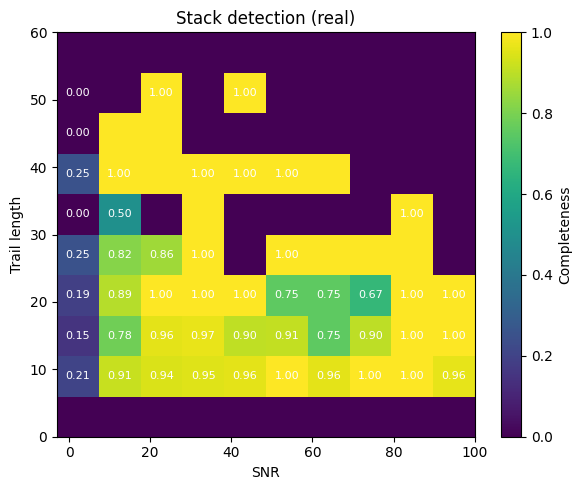

In [2]:
def _cm(col, fp):
    tp=int(ps[col].sum()); fn=int((~ps[col].astype(bool)).sum())
    return {"TP":tp,"FP":fp,"FN":fn,"TN":pd.NA}

evals.print_confusion_matrix(_cm('stack_detected', stack_fp),
    title="Per-sighting — LSST stack 5σ  (FP = diaSrc on 150 empty real panels)")
evals.plot_completeness_2d(cat, snr_bins=10, trail_bins=10, snr_range=(-3,100),
    trail_range=(0,60), detected=cat['stack_detection'].values,
    title="Stack detection (real)")
plt.show()

## v7 + RF (leak-free NN)

Per-sighting — v7 + RF NN  (FP = NN comps on 150 empty real panels)
F1 Score: 0.1094, F2 Score: 0.0874
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                 767
Actual Positive                2131                 178

Per-sighting — combined (stack OR NN)
F1 Score: 0.0435, F2 Score: 0.0980
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>               58881
Actual Positive                 947                1362



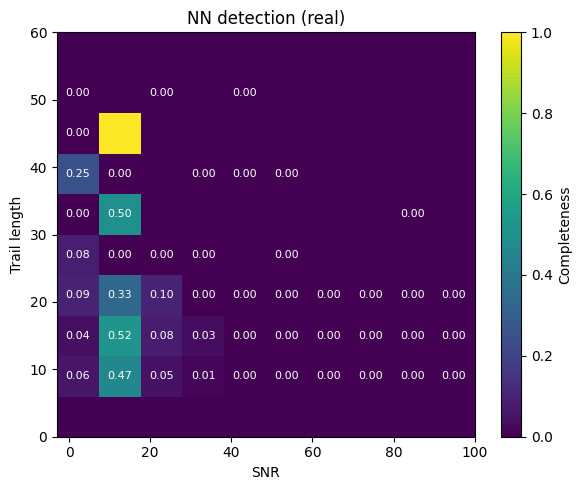

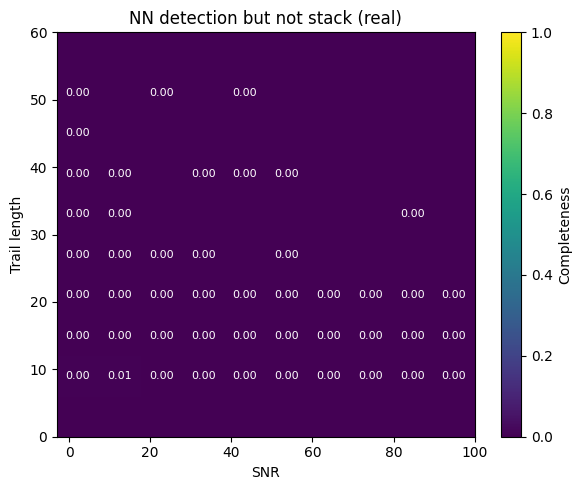

In [3]:
evals.print_confusion_matrix(_cm('nn_detected', nn_fp),
    title="Per-sighting — v7 + RF NN  (FP = NN comps on 150 empty real panels)")
comb = (ps.stack_detected.astype(bool) | ps.nn_detected.astype(bool))
evals.print_confusion_matrix({"TP":int(comb.sum()),"FP":stack_fp+nn_fp,
    "FN":int((~comb).sum()),"TN":pd.NA},
    title="Per-sighting — combined (stack OR NN)")
evals.plot_completeness_2d(cat, snr_bins=10, trail_bins=10, snr_range=(-3,100),
    trail_range=(0,60), detected=cat['nn_detected'].values,
    title="NN detection (real)")
plt.show()
evals.plot_completeness_2d(cat, snr_bins=10, trail_bins=10, snr_range=(-3,100),
    trail_range=(0,60),
    detected=(~cat['stack_detection'].values & cat['nn_detected'].values),
    title="NN detection but not stack (real)")
plt.show()

## Second-stage value (stack-missed only) + false positives

In [4]:
miss = ps[~ps.stack_detected.astype(bool)]
print(f"stack-missed sightings: {len(miss)} / {len(ps)}")
print(f"  NN recovers {int(miss.nn_detected.sum())} "
      f"({100*miss.nn_detected.mean():.1f}%)   <-- pure 2nd-stage gain")
g = ps.groupby('ObjID').agg(nn=('nn_detected','any'), st=('stack_detected','any'))
print(f"objects: stack {int(g.st.sum())}/{len(g)}  "
      f"combined {int((g.st|g.nn).sum())}/{len(g)}  "
      f"(NN-only NEW objects: {int((g.nn & ~g.st).sum())})")
print(f"\nFP on 150 empty real diffims:")
print(f"  NN          : {nn_fp} total  ({nn_fp/len(emp):.1f}/panel)")
print(f"  stack diaSrc: {stack_fp} total  ({stack_fp/len(emp):.0f}/panel)")

stack-missed sightings: 953 / 2309
  NN recovers 6 (0.6%)   <-- pure 2nd-stage gain
objects: stack 192/292  combined 193/292  (NN-only NEW objects: 1)

FP on 150 empty real diffims:
  NN          : 767 total  (5.1/panel)
  stack diaSrc: 58114 total  (387/panel)


# Completeness histograms

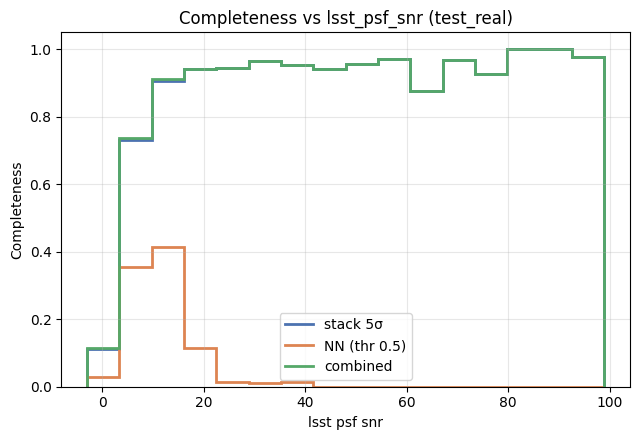

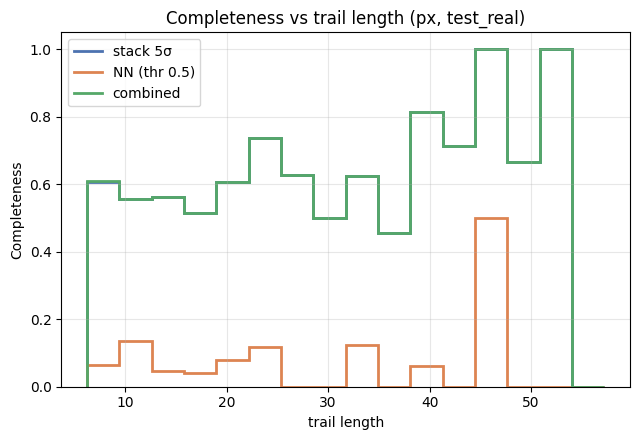

In [5]:
def plot_completeness(cat, field, bins=16, xlim=None, title=None, log_x=False):
    """density-mode completeness (detected/all per bin); curves: stack / NN / combined."""
    v = cat[field].to_numpy().astype(float); v = v[np.isfinite(v)]
    if xlim is not None: v = v[(v>=xlim[0]) & (v<=xlim[1])]
    edges = np.histogram_bin_edges(v, bins=bins)
    fig, ax = plt.subplots(figsize=(6.5,4.5))
    all_i = np.histogram(cat[field], bins=edges)[0].astype(float)
    for label, mask, color in [
        ('stack 5σ',     cat.stack_detection,                       '#4c72b0'),
        ('NN (thr 0.5)', cat.nn_detected,                           '#dd8452'),
        ('combined',     cat.stack_detection | cat.nn_detected,     '#55a868')]:
        det_i = np.histogram(cat[cat[field].notna() & mask][field], bins=edges)[0].astype(float)
        ax.stairs(det_i/np.maximum(all_i,1), edges, label=label, color=color, lw=2)
    ax.set_xlabel(field.replace('_',' ')); ax.set_ylabel('Completeness')
    if log_x: ax.set_xscale('symlog', linthresh=3)
    if title: ax.set_title(title)
    ax.grid(True, alpha=0.3); ax.set_ylim(0,1.05); ax.legend(loc='best')
    plt.tight_layout(); return fig, ax

plot_completeness(cat,'lsst_psf_snr',bins=16,xlim=(-3,100),
                  title='Completeness vs lsst_psf_snr (test_real)'); plt.show()
plot_completeness(cat,'trail_length',bins=16,xlim=(0,60),
                  title='Completeness vs trail length (px, test_real)'); plt.show()